In [2]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from scipy.stats import uniform, randint
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,  f1_score
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
import shap
import optuna

c:\Users\CTK109\Desktop\GTD\01. Projekty\ds_cloud_project\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
base_path = os.path.join(os.path.dirname(os.path.abspath('')), "data\\car_prices.csv")
df = pd.read_csv(base_path)

##### Explainable AI using **_SHAP_** values ​​– showing what actually affects price in the model

In [4]:
# RANDOM FOREST
median_price = df.groupby('make')['sellingprice'].quantile(0.75)
df['median_make'] = df['make'].map(median_price)
df['is_high_value'] = (df['sellingprice'] > df['median_make']).astype(int)
df['car_age'] = 2026 - df['year']

X = df[['car_age', 'condition']].fillna(0)
y = df['is_high_value']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
print(classification_report(y_test, y_pred_rf))

# %% GRID SEARCH FOR DECISION TREE
param_grid = {
    'max_depth': [3, 5, 10, 15],
    'min_samples_split': [2, 5, 50],
    'criterion': ['gini', 'entropy']
    }

base_tree = DecisionTreeClassifier(random_state=42)
# Cross-Validation at state 5
grid_search = GridSearchCV(estimator=base_tree, param_grid=param_grid, cv=5, scoring='f1')
grid_search.fit(X_train, y_train)

print(f"The best parameters: {grid_search.best_params_}")
print(f"The best score for F1: {grid_search.best_score_:.4f}")
y_pred_bg = grid_search.predict(X_test)
print(classification_report(y_test, y_pred_bg))

              precision    recall  f1-score   support

           0       0.81      0.93      0.87    126083
           1       0.62      0.34      0.44     41567

    accuracy                           0.78    167650
   macro avg       0.71      0.64      0.65    167650
weighted avg       0.76      0.78      0.76    167650

The best parameters: {'criterion': 'gini', 'max_depth': 5, 'min_samples_split': 2}
The best score for F1: 0.4872
              precision    recall  f1-score   support

           0       0.83      0.89      0.86    126083
           1       0.56      0.43      0.49     41567

    accuracy                           0.77    167650
   macro avg       0.69      0.66      0.67    167650
weighted avg       0.76      0.77      0.76    167650



              precision    recall  f1-score   support

           0       0.84      0.93      0.88    126083
           1       0.68      0.45      0.54     41567

    accuracy                           0.81    167650
   macro avg       0.76      0.69      0.71    167650
weighted avg       0.80      0.81      0.80    167650



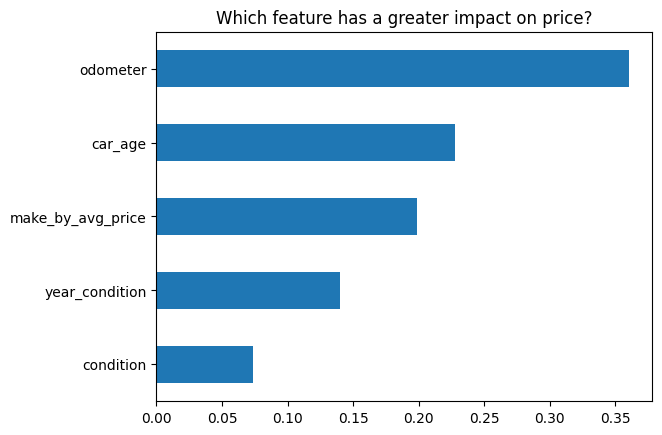

In [5]:
# XGBOOST
df['year_condition'] = df['year'] * df['condition']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df.drop('is_high_value', axis=1), 
    df['is_high_value'], 
    test_size=0.3, 
    random_state=42
)

# Unique brands described by mean price
# Protection against data leakage, making calcutaion only on training data
make_means_train = X_train_raw.groupby('make')['sellingprice'].mean()
global_mean_train = X_train_raw['sellingprice'].mean()

X_train_raw['make_by_avg_price'] = X_train_raw['make'].map(make_means_train)
# Filling gaps if make in test data doesn't exist in train data
X_test_raw['make_by_avg_price'] = X_test_raw['make'].map(make_means_train).fillna(global_mean_train)

features = ['car_age', 'condition', 'odometer', 'year_condition', 'make_by_avg_price']
X_train = X_train_raw[features]
X_test = X_test_raw[features]

# BEST PARAMETERS
xgb_model = XGBClassifier(
    n_estimators=611,
    learning_rate=0.13560151341533996,
    max_depth=9,
    random_state=42,
    eval_metric='logloss',
    colsample_bytree=0.6549515842095543,
    subsample=0.8952843331135384
)

xgb_model.fit(X_train, y_train)
# STOPS HERE

# XGBOOST WITH EARLY STOPPING
"""xgb_model = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    eval_metric='logloss',
    early_stopping_rounds=10
)

# Passing eval_set — the model will monitor the error on X_test
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False # to not trash console by logs from other trees   
)

print(f"Model had stopped on tree number: {xgb_model.best_iteration}")"""
# STOPS HERE

y_pred_xgb = xgb_model.predict(X_test)
print(classification_report(y_test, y_pred_xgb))

importances = pd.Series(xgb_model.feature_importances_, index=features)
importances.sort_values().plot(kind='barh')
plt.title("Which feature has a greater impact on price?")
plt.show()

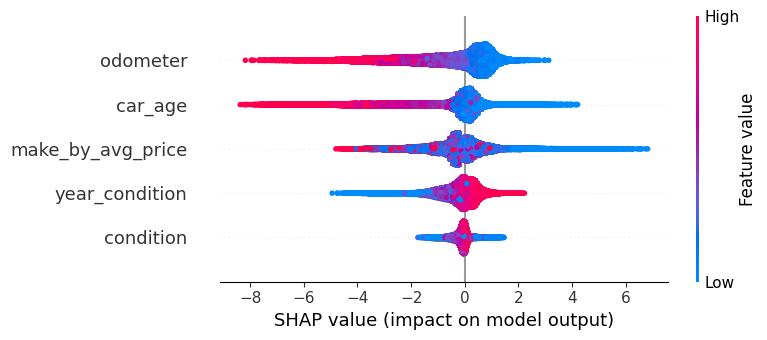

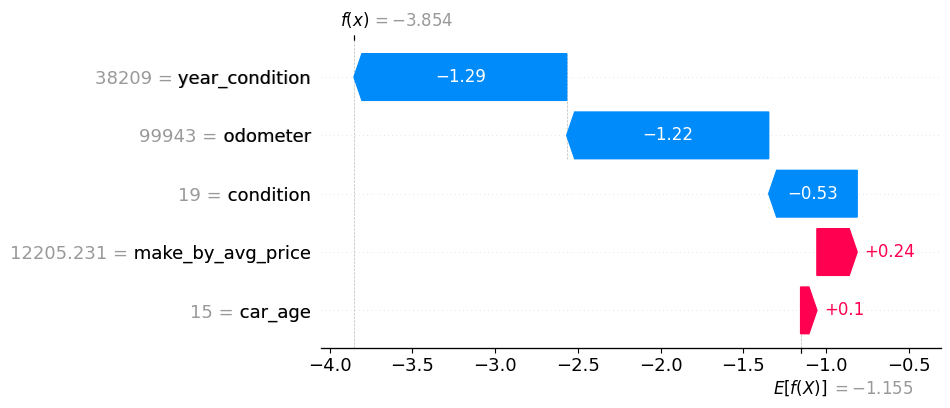

Probability of Toyota, Corolla is expensive: 0.02


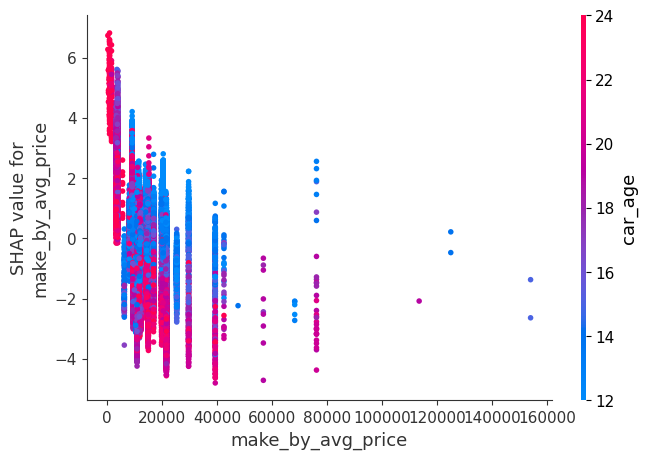

'When the shap library was called to generate a chart for the brand, \nit automatically identified the second attribute (car_age) \nthat correlates most strongly with the brand.'

In [6]:
# EXPLAINING XGBOOST'S DECISIONS
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)

sample_idx = 0
shap_values_sample = explainer(X_test.iloc[sample_idx:sample_idx+1])

# Waterfall chart
shap.plots.waterfall(shap_values_sample[0])

final_log_odds = shap_values_sample[0].base_values + shap_values_sample[0].values.sum()
actual_car_info = df.iloc[X_test.index[sample_idx]]
probability = 1 / (1 + np.exp(-final_log_odds))

print(f"Probability of {actual_car_info['make']}, {actual_car_info['model']} is expensive: {probability:.2f}")

# The impact of the brand on price
shap.dependence_plot("make_by_avg_price", shap_values, X_test)

"""When the shap library was called to generate a chart for the brand, 
it automatically identified the second attribute (car_age) 
that correlates most strongly with the brand."""

_**SHAP** values reveal that 'car age' and 'odometer' have the highest impact on pricing, confirming the model aligns with domain knowledge._

*This model had better results with finding luxury brands than Decision Tree or Random Forest. But the game changer is adding feature of unique brands based on average price.*

In [7]:
# Searching the best parameters by RandomSearch
param_dist = {
    'n_estimators': randint(100, 1000),
    'max_depth': randint(3, 10),
    'learning_rate': uniform(0.01, 0.2),
    'subsample': uniform(0.6, 0.4), # from 0.6 to 1.0
    'colsample_bytree': uniform(0.6, 0.4)
}

random_search = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    param_distributions=param_dist,
    n_iter=20, # how many combinations to check
    cv=3,
    scoring='f1',
    random_state=42,
    verbose=3, # this is the calculating view
    n_jobs=-1 # use all procesor cores
)

random_search.fit(X_train, y_train)
print(f"The best params from RandomSearch are: {random_search.best_params_}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits
The best params from RandomSearch are: {'colsample_bytree': np.float64(0.88453678109946), 'learning_rate': np.float64(0.16803510810624114), 'max_depth': 5, 'n_estimators': 872, 'subsample': np.float64(0.9705203514053395)}


In [ ]:
# Searching the best parameters by Bayesian Optimization
def objective(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'eval_metric': 'logloss',
        'random_state': 42
    }
    
    model = XGBClassifier(**param)
    model.fit(X_train, y_train)
    
    preds = model.predict(X_test)
    return f1_score(y_test, preds)

# Creating study and searching for max f1_score
# Saving to a file - can pause and resume at any time
study = optuna.create_study(
    study_name="auto_valuation", 
    storage="sqlite:///optuna_study.db", 
    load_if_exists=True,
    direction="maximize"
)
study.optimize(objective, n_trials=30, show_progress_bar=True)

print(f"The best params from Optuna are: {study.best_params}")

[I 2026-05-03 08:53:38,041] A new study created in RDB with name: auto_valuation
Best trial: 0. Best value: 0.534535:   3%|▎         | 1/30 [00:19<09:38, 19.94s/it]

[I 2026-05-03 08:53:57,975] Trial 0 finished with value: 0.5345352445692331 and parameters: {'n_estimators': 393, 'max_depth': 7, 'learning_rate': 0.19681960937662735, 'subsample': 0.9472869739313124, 'colsample_bytree': 0.5857604338103433}. Best is trial 0 with value: 0.5345352445692331.


Best trial: 1. Best value: 0.5393:   7%|▋         | 2/30 [00:55<13:43, 29.39s/it]  

[I 2026-05-03 08:54:33,954] Trial 1 finished with value: 0.5393000085157115 and parameters: {'n_estimators': 352, 'max_depth': 10, 'learning_rate': 0.18382993940005407, 'subsample': 0.6937331532008288, 'colsample_bytree': 0.9404070082905385}. Best is trial 1 with value: 0.5393000085157115.


Best trial: 1. Best value: 0.5393:  10%|█         | 3/30 [01:44<17:03, 37.92s/it]

...

[I 2026-05-03 09:09:34,416] Trial 27 finished with value: 0.5356337326810978 and parameters: {'n_estimators': 493, 'max_depth': 9, 'learning_rate': 0.1359148983298526, 'subsample': 0.89188318182218, 'colsample_bytree': 0.538244541433334}. Best is trial 24 with value: 0.5425994756101075.


Best trial: 24. Best value: 0.542599:  97%|█████████▋| 29/30 [16:17<00:31, 31.63s/it]

[I 2026-05-03 09:09:56,034] Trial 28 finished with value: 0.5360088855979267 and parameters: {'n_estimators': 402, 'max_depth': 7, 'learning_rate': 0.0962491213311937, 'subsample': 0.7420195104787126, 'colsample_bytree': 0.6788429378400215}. Best is trial 24 with value: 0.5425994756101075.


Best trial: 24. Best value: 0.542599: 100%|██████████| 30/30 [16:37<00:00, 33.27s/it]

[I 2026-05-03 09:10:16,030] Trial 29 finished with value: 0.5394851240034777 and parameters: {'n_estimators': 391, 'max_depth': 6, 'learning_rate': 0.19513422162292912, 'subsample': 0.9484790234843052, 'colsample_bytree': 0.6196653674648648}. Best is trial 24 with value: 0.5425994756101075.
The best params from Optuna are: {'n_estimators': 611, 'max_depth': 9, 'learning_rate': 0.13560151341533996, 'subsample': 0.8952843331135384, 'colsample_bytree': 0.6549515842095543}
